# 01 — Exploratory Data Analysis

Universe: ~120 NSE large/mid-cap stocks, daily adjusted OHLCV, 2015-01-01 to 2025-06-30.

This notebook answers three questions before any modelling happens:
1. Is the data actually usable (gaps, staleness, extreme moves)?
2. What does the return/volatility landscape of this universe look like?
3. What does the raw correlation structure look like, and why does that motivate
   both the correlation filter (Phase 3) and covariance shrinkage (Phase 2)?

Run `python scripts/fetch_data.py` first if `data/processed/` is empty.


In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from riskengine.config import DATA_PROCESSED, TABLES
from riskengine.data import get_universe, sector_map

pd.set_option("display.max_rows", 30)
plt.rcParams["figure.dpi"] = 110


## 1. Universe

124 tickers across 17 sectors


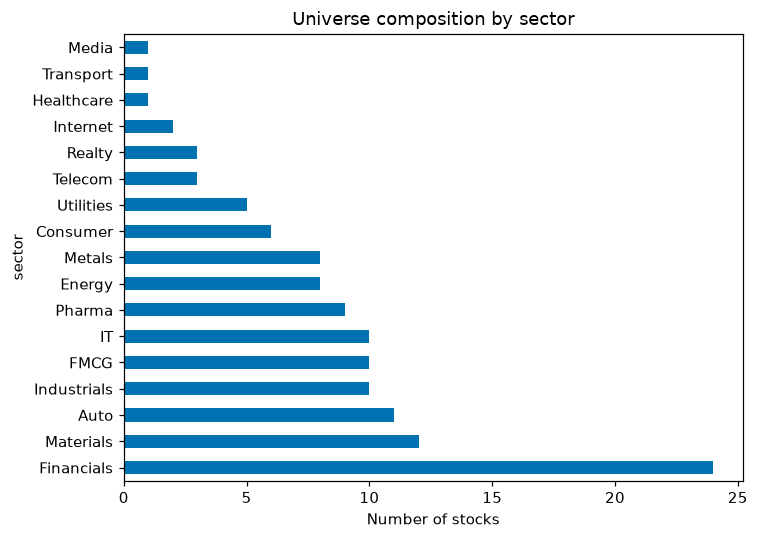

In [2]:
universe = get_universe()
print(f"{len(universe)} tickers across {universe['sector'].nunique()} sectors")
universe["sector"].value_counts().plot(kind="barh", figsize=(7,5), color="#0072B2")
plt.title("Universe composition by sector")
plt.xlabel("Number of stocks")
plt.tight_layout()
plt.show()


## 2. Data quality audit

See `riskengine.data.quality.data_quality_report` for the classification logic — this is the same report `scripts/fetch_data.py` writes to `results/tables/data_quality_report.csv`.

In [3]:
report = pd.read_csv(TABLES / "data_quality_report.csv", index_col=0)
print(report["status"].value_counts())
report.sort_values("missing_frac", ascending=False).head(10)


status
ok                 122
download_failed      2
Name: count, dtype: int64


,n_obs,first_date,last_date,missing_frac,stale_frac,n_extreme,status
ticker,,,,,,,
LTIM.NS,0,NaN,NaN,1.0,NaN,0,download_failed
TATAMOTORS.NS,0,NaN,NaN,1.0,NaN,0,download_failed
ABB.NS,2581,2015-01-02,2025-06-27,0.0,0.0019,0,ok
ACC.NS,2581,2015-01-02,2025-06-27,0.0,0.0008,0,ok
ADANIENT.NS,2581,2015-01-02,2025-06-27,0.0,0.0039,0,ok
ADANIPORTS.NS,2581,2015-01-02,2025-06-27,0.0,0.0062,0,ok
ALKEM.NS,2343,2015-12-23,2025-06-27,0.0,0.0030,0,ok
AMBUJACEM.NS,2581,2015-01-02,2025-06-27,0.0,0.0058,0,ok
APOLLOHOSP.NS,2581,2015-01-02,2025-06-27,0.0,0.0008,0,ok


**Two tickers failed to download entirely**: `LTIM.NS` and `TATAMOTORS.NS` — both hit Yahoo Finance 404s consistent with 2025 corporate-action symbol changes (Tata Motors demerger). They are excluded from the clean panel and this is disclosed in `docs/methodology.md`, not silently absorbed.

## 3. Return and volatility landscape

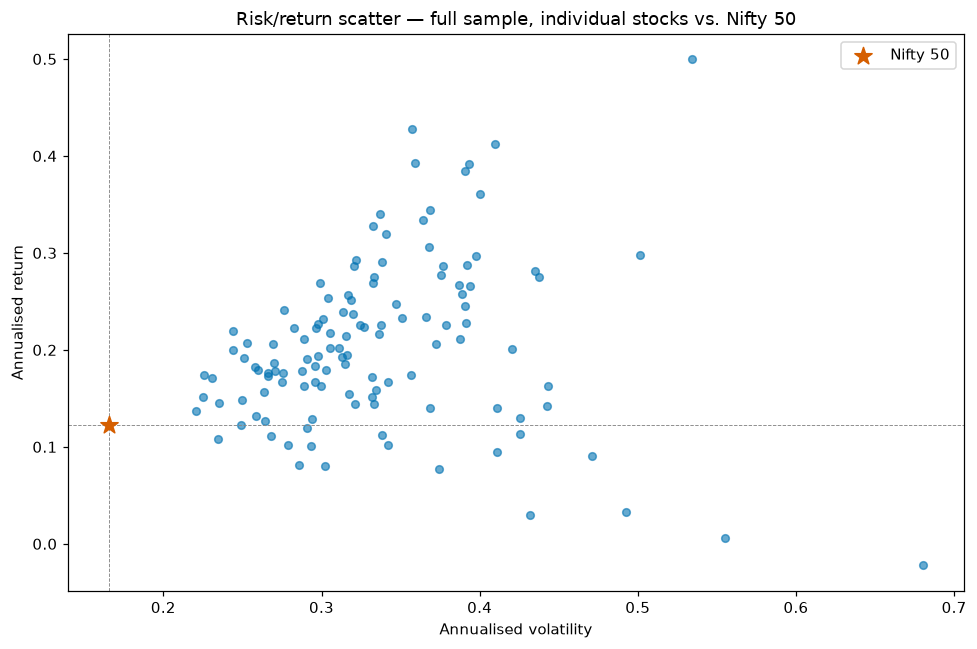

Universe median annual return: 19.7%  |  Nifty 50: 12.3%
Universe median annual vol:    32.1%  |  Nifty 50: 16.6%


In [4]:
close = pd.read_parquet(DATA_PROCESSED / "close.parquet")
bench = pd.read_parquet(DATA_PROCESSED / "benchmark.parquet")["close"]
rets = close.pct_change()

ann_ret = rets.mean() * 252
ann_vol = rets.std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(ann_vol, ann_ret, alpha=0.6, color="#0072B2", s=25)
bench_ret = bench.pct_change().mean()*252
bench_vol = bench.pct_change().std()*np.sqrt(252)
ax.scatter([bench_vol], [bench_ret], color="#D55E00", s=140, marker="*", label="Nifty 50", zorder=5)
ax.axhline(bench_ret, color="#888", lw=0.6, ls="--")
ax.axvline(bench_vol, color="#888", lw=0.6, ls="--")
ax.set_xlabel("Annualised volatility")
ax.set_ylabel("Annualised return")
ax.set_title("Risk/return scatter — full sample, individual stocks vs. Nifty 50")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Universe median annual return: {ann_ret.median():.1%}  |  Nifty 50: {bench_ret:.1%}")
print(f"Universe median annual vol:    {ann_vol.median():.1%}  |  Nifty 50: {bench_vol:.1%}")


**Note the survivorship signal here already**: the median stock in this universe outperformed the Nifty 50 over 2015-2025. That is partly genuine (large/mid-caps *did* outperform the broader index this period) and partly the survivorship bias documented in `docs/methodology.md#survivorship` — this universe excludes anything that got removed from consideration along the way.

## 4. Correlation structure — why shrinkage and a correlation filter both matter

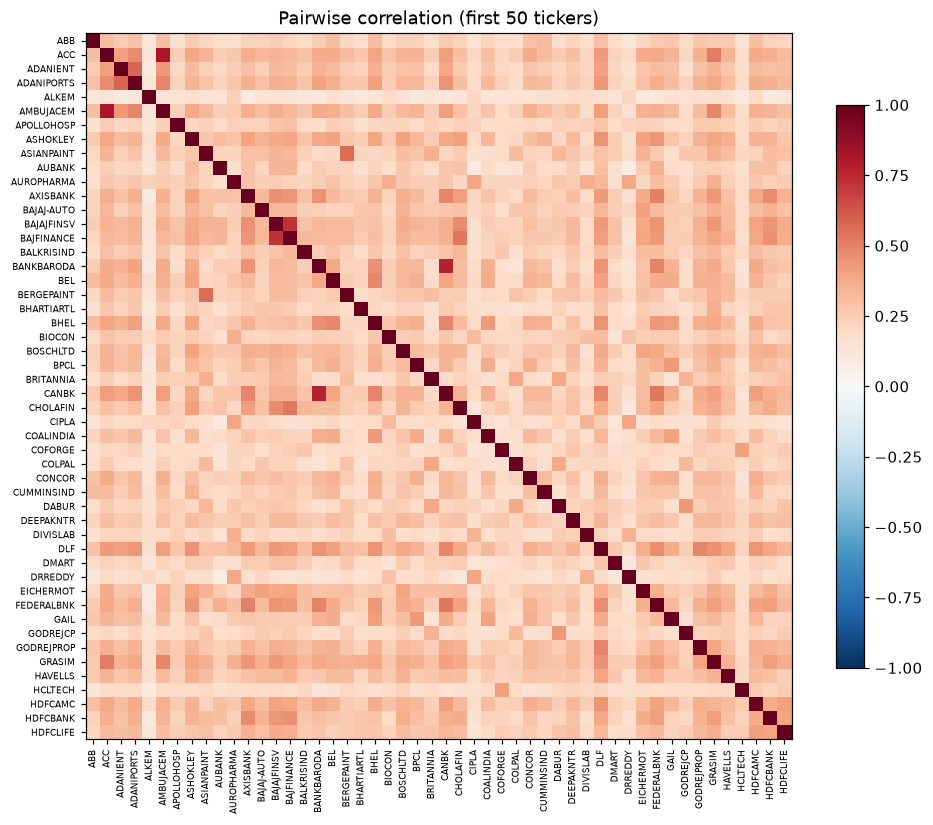

Mean pairwise correlation: 0.27  |  Max: 0.81


In [5]:
corr = rets.iloc[:, :50].corr()
fig, ax = plt.subplots(figsize=(9,8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels([c.replace(".NS","") for c in corr.columns], rotation=90, fontsize=6)
ax.set_yticks(range(len(corr))); ax.set_yticklabels([c.replace(".NS","") for c in corr.index], fontsize=6)
fig.colorbar(im, shrink=0.7)
ax.set_title("Pairwise correlation (first 50 tickers)")
plt.tight_layout()
plt.show()

offdiag = corr.to_numpy()[~np.eye(len(corr), dtype=bool)]
print(f"Mean pairwise correlation: {offdiag.mean():.2f}  |  Max: {offdiag.max():.2f}")


Sector clusters (banks, IT) show visibly higher correlation blocks than the cross-sector average — this is exactly what the correlation filter in `optimize/constraints.py` (drop the lower-ranked half of any pair correlated above 0.85) and the sector cap in the backtest engine are designed to prevent the score-based allocator from exploiting: without them, "top 25 by Sharpe" would frequently just mean "12 banks and 8 IT stocks.

## 5. Volatility clustering — the empirical fact the Phase 5 model exploits

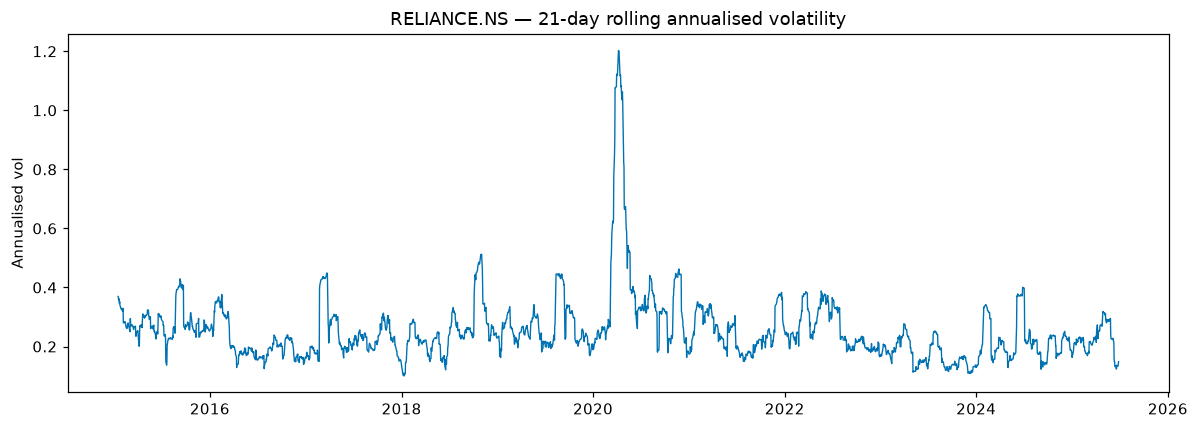

In [6]:
from riskengine.features.volatility import realised_vol

example = "RELIANCE.NS" if "RELIANCE.NS" in rets.columns else rets.columns[0]
rv = realised_vol(rets[[example]], window=21)

fig, ax = plt.subplots(figsize=(11,4))
ax.plot(rv.index, rv[example], color="#0072B2", lw=0.9)
ax.set_title(f"{example} — 21-day rolling annualised volatility")
ax.set_ylabel("Annualised vol")
plt.tight_layout()
plt.show()


Volatility visibly clusters into regimes (calm 2017, the 2020 COVID spike, elevated 2022) rather than being i.i.d. noise around a constant level — this persistence is precisely what makes 21-day-forward volatility forecastable, and is the motivating fact for Phase 5 (`notebooks/03_volatility_model.ipynb`).